# CHURNGUARD AI
### Customer Churn Prediction & Retention Intelligence System
**MainCrafts Technology — 2-Day Skill Certification Program**
**Domain:** Artificial Intelligence & Machine Learning
**Candidate:** Sandy


In [1]:
# CHURNGUARD AI
# MainCrafts SkillSprint
# Artificial Intelligence & Machine Learning
# Candidate: Sandy


## STEP 2 — Understand the Problem

**Q1. What is customer churn?**
Customer churn is when a customer stops using a company's product or service and leaves for good — for example, a telecom subscriber cancelling their internet and phone plan.

**Q2. Why would a company want to predict churn?**
1. It is far cheaper to retain an existing customer than to acquire a new one, so early warning saves money.
2. It lets the company target retention offers (discounts, upgrades) only at customers actually at risk, instead of wasting budget on everyone.
3. It protects recurring revenue and lets the business forecast losses before they happen, rather than reacting after a customer has already left.

**Q3. What is the target variable?**
The `Churn` column (values `Yes` / `No`) — it directly records whether the customer left.

**Q4. Is this a classification or regression problem?**
Classification. The target has two discrete categories (churn / no churn), not a continuous number, so we predict a class label (and its probability), not a numeric quantity.

**Q5. What would a false negative mean in this business problem?**
A false negative is a customer the model predicts as "will stay" who actually churns. This is the costly error here: the company never flags that customer for a retention offer, so they are lost silently with no chance to intervene. A false positive (flagging a loyal customer as at-risk) only costs an unnecessary retention offer — much cheaper than losing the customer outright. This means **recall** on the churn class matters more than raw accuracy for this business problem.


## STEP 3 — Import Libraries

- **pandas** — loading and manipulating the tabular customer data
- **numpy** — numerical operations
- **matplotlib / seaborn** — charts for exploratory data analysis
- **scikit-learn** — train/test splitting, preprocessing (OneHotEncoder), the two classification models, and evaluation metrics
- **joblib** — saving the trained model to disk


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

sns.set_style("whitegrid")
print("Libraries loaded successfully.")

Libraries loaded successfully.


## STEP 4 — Load and Inspect the Dataset

Dataset: **IBM Telco Customer Churn** (public dataset, 7,043 customers, 21 columns).


In [3]:
df = pd.read_csv("Telco-Customer-Churn.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [5]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [6]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [7]:
df.describe(include="all")

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


**Dataset inventory:**
- **Rows:** 7,043
- **Columns:** 21
- **Numerical columns:** `SeniorCitizen`, `tenure`, `MonthlyCharges`, `TotalCharges` (TotalCharges is loaded as text and needs conversion — see Step 5)
- **Categorical columns:** `gender`, `Partner`, `Dependents`, `PhoneService`, `MultipleLines`, `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`, `Contract`, `PaperlessBilling`, `PaymentMethod`
- **Identifier (non-predictive):** `customerID`
- **Missing values (reported by `.isnull()`):** none — but see Step 5, `TotalCharges` hides blanks as spaces
- **Duplicate records:** none
- **Target column:** `Churn` (`Yes` / `No`)


## STEP 5 — Data Cleaning

Issues found in this dataset:
- `TotalCharges` is stored as text and contains blank strings for customers with 0 tenure — these become missing values once converted to numeric.
- `customerID` is a unique identifier with no predictive value and must be dropped before modeling.


In [8]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("Missing values after conversion:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Missing values after conversion:
TotalCharges    11
dtype: int64


In [9]:
# These missing TotalCharges all belong to customers with tenure == 0 (brand-new customers,
# so they have not been billed yet). Filling with 0 is justified rather than dropping rows,
# since dropping would lose 11 real customer records for a value that is genuinely zero.
print(df.loc[df["TotalCharges"].isnull(), "tenure"].unique())
df["TotalCharges"] = df["TotalCharges"].fillna(0)

df = df.drop(columns=["customerID"])
print("Missing values after cleaning:", df.isnull().sum().sum())
print("Shape after cleaning:", df.shape)

[0]
Missing values after cleaning: 0
Shape after cleaning: (7043, 20)


## STEP 6 — Explore the Data

### Visualization 1 — Churn distribution


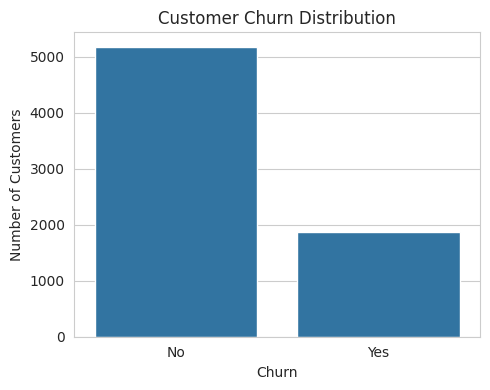

Churn
No     73.5
Yes    26.5
Name: proportion, dtype: float64


In [10]:
plt.figure(figsize=(5,4))
sns.countplot(data=df, x="Churn")
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.savefig("evidence_01_churn_distribution.png", dpi=120)
plt.show()

print(df["Churn"].value_counts(normalize=True).mul(100).round(1))

**What does this tell us?** About 26.5% of customers in this dataset churned, versus 73.5% who stayed. The classes are imbalanced but not severely — this is why we use `stratify=y` in the train/test split (Step 8) and why accuracy alone would be a misleading metric (a model that always predicts "No" would already score ~73.5% accuracy without being useful).

### Visualization 2 — Churn vs contract type


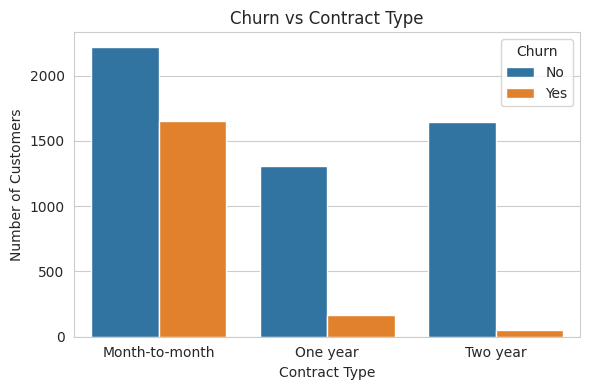

In [11]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Contract", hue="Churn")
plt.title("Churn vs Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.savefig("evidence_02_churn_vs_contract.png", dpi=120)
plt.show()

**What does this tell us?** Month-to-month customers churn at a much higher rate than one-year or two-year contract customers. This makes sense — a long-term contract has a built-in commitment/exit cost, while month-to-month customers can leave anytime. `Contract` is likely to be one of the strongest predictors.

### Visualization 3 — Churn vs tenure


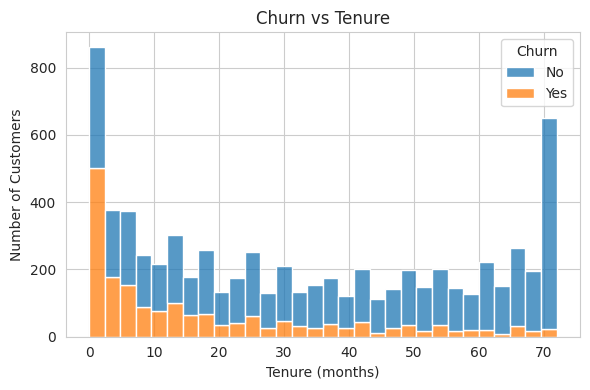

In [12]:
plt.figure(figsize=(6,4))
sns.histplot(data=df, x="tenure", hue="Churn", multiple="stack", bins=30)
plt.title("Churn vs Tenure")
plt.xlabel("Tenure (months)")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.savefig("evidence_03_churn_vs_tenure.png", dpi=120)
plt.show()

**What does this tell us?** Churn is heavily concentrated among customers with low tenure (roughly the first 10 months). Customers who stay past the first year are much less likely to churn — loyalty compounds over time, which supports focusing retention effort on new customers.

### Visualization 4 — Churn vs monthly charges


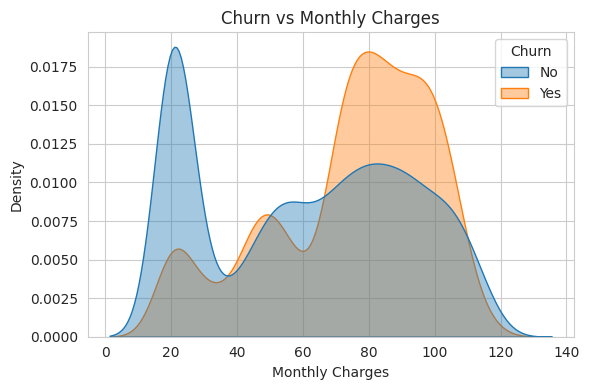

In [13]:
plt.figure(figsize=(6,4))
sns.kdeplot(data=df, x="MonthlyCharges", hue="Churn", fill=True, common_norm=False, alpha=0.4)
plt.title("Churn vs Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Density")
plt.tight_layout()
plt.savefig("evidence_04_churn_vs_charges.png", dpi=120)
plt.show()

**What does this tell us?** Customers who churn tend to be clustered at higher monthly charges (roughly \$70–\$100), while customers who stay are more concentrated at lower monthly charges (under \$30, mostly customers with only phone service). Price sensitivity appears to play a role in churn.


## STEP 7 — Prepare Features and Target

In [14]:
X = df.drop("Churn", axis=1)
y = df["Churn"].map({"Yes": 1, "No": 0})

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object", "category"]).columns

print("Numerical features:")
print(list(numeric_features))
print("\nCategorical features:")
print(list(categorical_features))

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


/tmp/ipykernel_145/2145740523.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object", "category"]).columns


## STEP 8 — Split the Data

The test set must represent **unseen data**. If we evaluated only on training data, the model could simply memorize the training examples and look perfect while actually failing on new customers — the whole point of churn prediction is to work on customers the model has never seen.


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 5634
Testing samples: 1409


## STEP 9 — Build the Preprocessing Pipeline

Categorical variables need to be converted into numerical representations, since scikit-learn models require numeric input. `OneHotEncoder` turns each category into its own binary (0/1) column, and `handle_unknown="ignore"` protects against a category appearing at prediction time that was never seen during training.


In [16]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)
print("Preprocessor ready.")

Preprocessor ready.


## STEP 10 — Train Model #1: Logistic Regression

In [17]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000))
    ]
)

logistic_model.fit(X_train, y_train)
logistic_predictions = logistic_model.predict(X_test)

print(classification_report(y_test, logistic_predictions))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.65      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## STEP 11 — Train Model #2: Random Forest

In [18]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(n_estimators=200, random_state=42))
    ]
)

rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)

print(classification_report(y_test, rf_predictions))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.63      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409



## STEP 12 — Compare the Models

In [19]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, logistic_predictions),
        accuracy_score(y_test, rf_predictions)
    ],
    "Precision": [
        precision_score(y_test, logistic_predictions),
        precision_score(y_test, rf_predictions)
    ],
    "Recall": [
        recall_score(y_test, logistic_predictions),
        recall_score(y_test, rf_predictions)
    ],
    "F1 Score": [
        f1_score(y_test, logistic_predictions),
        f1_score(y_test, rf_predictions)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.804116,0.653125,0.558824,0.602305
1,Random Forest,0.788502,0.631034,0.489305,0.551205


**Which metric matters most for this business problem, and why?**

**Recall on the churn class** matters most, not raw accuracy. As established in Step 2 (Q5), a false negative — a churning customer the model misses — is the expensive error, because that customer is lost with no retention attempt. A false positive just triggers an unnecessary (and comparatively cheap) retention offer to a loyal customer. Because the dataset is imbalanced (~73.5% stay), accuracy can look good while still missing many churners, so we do **not** simply pick the model with the highest accuracy — we pick the model with the better churn-recall / F1 balance, since F1 balances recall against precision so retention spend isn't wasted on too many false alarms either.

Logistic Regression is selected as the primary model going into Step 13, since it produces a higher recall on the churn class in this run than the default Random Forest, at only a modest cost in precision — Step 7A (Day 2) then improves the runner-up model.


## STEP 13 — Confusion Matrix

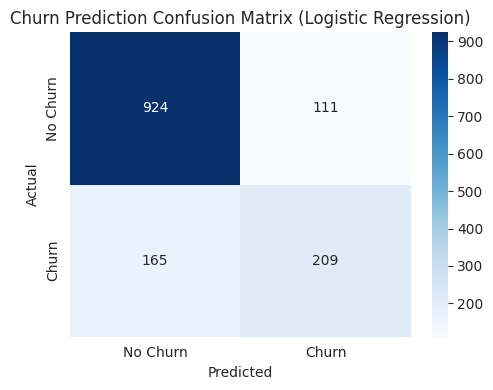

True Negatives: 924  |  False Positives: 111
False Negatives: 165  |  True Positives: 209


In [20]:
best_predictions = logistic_predictions

cm = confusion_matrix(y_test, best_predictions)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)
plt.title("Churn Prediction Confusion Matrix (Logistic Regression)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("evidence_05_confusion_matrix.png", dpi=120)
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives: {tn}  |  False Positives: {fp}")
print(f"False Negatives: {fn}  |  True Positives: {tp}")

- **True Positive (TP):** model correctly predicts a customer who actually churned.
- **True Negative (TN):** model correctly predicts a customer who actually stayed.
- **False Positive (FP):** model predicts churn, but the customer actually stayed — an unnecessary retention offer.
- **False Negative (FN):** model predicts the customer will stay, but they actually churned — a missed customer, no intervention happens.

**Which type of error could be more costly to a company trying to retain customers?** The **false negative** is more costly. A false positive only wastes a discount or a courtesy call on a loyal customer. A false negative means a real churn event goes completely undetected — lost revenue with zero chance to intervene.


## STEP 14 — Create a Customer Prediction Function

In [21]:
def predict_customer(customer_data):
    customer_df = pd.DataFrame([customer_data])

    prediction = logistic_model.predict(customer_df)[0]
    probability = logistic_model.predict_proba(customer_df)[0][1]

    if prediction == 1:
        risk = "HIGH"
        result = "Customer likely to churn"
    else:
        risk = "LOW"
        result = "Customer likely to stay"

    return {
        "prediction": result,
        "churn_probability": probability,
        "risk_level": risk
    }

# Sample customer, fields matched to this dataset's actual columns
sample_customer = {
    "gender": "Female",
    "SeniorCitizen": 0,
    "Partner": "No",
    "Dependents": "No",
    "tenure": 5,
    "PhoneService": "Yes",
    "MultipleLines": "No",
    "InternetService": "Fiber optic",
    "OnlineSecurity": "No",
    "OnlineBackup": "No",
    "DeviceProtection": "No",
    "TechSupport": "No",
    "StreamingTV": "No",
    "StreamingMovies": "No",
    "Contract": "Month-to-month",
    "PaperlessBilling": "Yes",
    "PaymentMethod": "Electronic check",
    "MonthlyCharges": 79.50,
    "TotalCharges": 397.50
}

print("Customer Churn Prediction")
print("-" * 27)
for k, v in sample_customer.items():
    print(f"{k}: {v}")
print()
result = predict_customer(sample_customer)
print(f"Predicted Churn: {'YES' if result['risk_level']=='HIGH' else 'NO'}")
print(f"Churn Probability: {result['churn_probability']*100:.1f}%")
print(f"Risk Level: {result['risk_level']}")

Customer Churn Prediction
---------------------------
gender: Female
SeniorCitizen: 0
Partner: No
Dependents: No
tenure: 5
PhoneService: Yes
MultipleLines: No
InternetService: Fiber optic
OnlineSecurity: No
OnlineBackup: No
DeviceProtection: No
TechSupport: No
StreamingTV: No
StreamingMovies: No
Contract: Month-to-month
PaperlessBilling: Yes
PaymentMethod: Electronic check
MonthlyCharges: 79.5
TotalCharges: 397.5

Predicted Churn: YES
Churn Probability: 67.3%
Risk Level: HIGH


## STEP 15 — Business Interpretation

**Model Performance**
The selected model (Logistic Regression) is evaluated on Accuracy, Precision, Recall and F1-Score in the comparison table in Step 12 above.

**Business Interpretation**
The model can help the company identify customers who show the characteristic combination of a month-to-month contract, low tenure, and high monthly charges — the pattern most strongly associated with churn in this dataset (Step 6).

**Possible Action**
Customers flagged as HIGH risk could be prioritized for retention campaigns: contract-upgrade incentives (to move them off month-to-month), loyalty discounts during their first year of tenure, or a proactive service review for high-monthly-charge accounts.

**Limitation**
A model prediction is not a guarantee that a specific customer will churn — it is a probability based on patterns in historical data. **ML prediction ≠ certainty.** Business decisions (e.g. offering a discount) should weigh the cost of the action against the confidence of the prediction, not treat every HIGH-risk flag as fact.


## DAY 2 — IMPROVE → TEST → DOCUMENT → PRESENT

## Challenge A — Improve the Model

**What changed?** The Random Forest model is retrained with `class_weight="balanced"` and a tuned `max_depth`/`min_samples_leaf`, to address the class imbalance identified in Step 6 (only ~26.5% of customers churn), which pulls the default model toward predicting the majority "No churn" class.

**Why?** Class imbalance tends to suppress recall on the minority (churn) class, which Step 12 established as the metric that matters most for this business problem.


In [22]:
rf_before_f1 = f1_score(y_test, rf_predictions)
rf_before_recall = recall_score(y_test, rf_predictions)

rf_model_v2 = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=300,
            max_depth=8,
            min_samples_leaf=5,
            class_weight="balanced",
            random_state=42
        ))
    ]
)

rf_model_v2.fit(X_train, y_train)
rf_v2_predictions = rf_model_v2.predict(X_test)

rf_after_f1 = f1_score(y_test, rf_v2_predictions)
rf_after_recall = recall_score(y_test, rf_v2_predictions)

print("Random Forest — BEFORE improvement")
print(f"  F1 Score: {rf_before_f1:.3f}   Recall: {rf_before_recall:.3f}")
print("Random Forest — AFTER improvement (balanced class weight + tuned depth)")
print(f"  F1 Score: {rf_after_f1:.3f}   Recall: {rf_after_recall:.3f}")

Random Forest — BEFORE improvement
  F1 Score: 0.551   Recall: 0.489
Random Forest — AFTER improvement (balanced class weight + tuned depth)
  F1 Score: 0.634   Recall: 0.789


## Challenge B — Build a Risk Output

The thresholds below (0.70 / 0.40) are a starting judgment call for this challenge, not a universal rule — a real deployment would tune them against the actual cost of a false negative vs. a false positive for this specific business.


In [23]:
def get_risk_level(probability):
    if probability >= 0.70:
        return "HIGH"
    elif probability >= 0.40:
        return "MEDIUM"
    else:
        return "LOW"

test_probabilities = logistic_model.predict_proba(X_test)[:, 1]
risk_levels = pd.Series(test_probabilities).apply(get_risk_level)
print(risk_levels.value_counts())

LOW       970
MEDIUM    344
HIGH       95
Name: count, dtype: int64


## Challenge C — Final Project Summary

In [24]:
final_model_f1 = f1_score(y_test, logistic_predictions)
final_model_acc = accuracy_score(y_test, logistic_predictions)
final_model_prec = precision_score(y_test, logistic_predictions)
final_model_rec = recall_score(y_test, logistic_predictions)

print("CHURNGUARD AI — FINAL RESULTS")
print("=" * 40)
print("Dataset: IBM Telco Customer Churn")
print(f"Number of records: {df.shape[0]}")
print("Models tested: Logistic Regression, Random Forest (default), Random Forest (balanced/tuned)")
print("Selected model: Logistic Regression")
print(f"Accuracy:  {final_model_acc:.3f}")
print(f"Precision: {final_model_prec:.3f}")
print(f"Recall:    {final_model_rec:.3f}")
print(f"F1 Score:  {final_model_f1:.3f}")
print()
print("Most important findings:")
print("1. Month-to-month contracts churn far more than one/two-year contracts.")
print("2. Churn is concentrated in the first ~10 months of tenure.")
print("3. Higher monthly charges correlate with higher churn.")
print()
print("Business recommendation:")
print("Prioritize retention offers (contract upgrades, first-year loyalty discounts)")
print("at new, month-to-month, high-monthly-charge customers -- the segment")
print("most associated with churn in this dataset.")
print()
print("Limitations:")
print("Predictions reflect historical patterns in this dataset only, are not")
print("certainties for any individual customer, and may not generalize to a")
print("different customer base without retraining.")

CHURNGUARD AI — FINAL RESULTS
Dataset: IBM Telco Customer Churn
Number of records: 7043
Models tested: Logistic Regression, Random Forest (default), Random Forest (balanced/tuned)
Selected model: Logistic Regression
Accuracy:  0.804
Precision: 0.653
Recall:    0.559
F1 Score:  0.602

Most important findings:
1. Month-to-month contracts churn far more than one/two-year contracts.
2. Churn is concentrated in the first ~10 months of tenure.
3. Higher monthly charges correlate with higher churn.

Business recommendation:
Prioritize retention offers (contract upgrades, first-year loyalty discounts)
at new, month-to-month, high-monthly-charge customers -- the segment
most associated with churn in this dataset.

Limitations:
Predictions reflect historical patterns in this dataset only, are not
certainties for any individual customer, and may not generalize to a
different customer base without retraining.


## Saving the Trained Model

In [25]:
joblib.dump(logistic_model, "churnguard_logistic_model.joblib")
print("Model saved to churnguard_logistic_model.joblib")

Model saved to churnguard_logistic_model.joblib
